In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [6]:
df = pd.read_csv(r'D:\Digicrome file (Imp)\NextHikes IT Solutions (Projects)\Project 4\Processed_Flipdata - Processed_Flipdata.csv', encoding= 'unicode_escape')

In [7]:
df.describe()
df.shape
df.head(10)

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"
5,5,Infinix HOT 30i,Glacier Blue,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"
6,6,Infinix HOT 30i,Mirror Black,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"
7,7,Infinix HOT 30i,Diamond White,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"
8,8,Infinix HOT 30i,Diamond White,64,4,5000,50MP,5MP,1,16.76,G37,"7,999"
9,9,Infinix HOT 30i,Mirror Black,64,4,5000,50MP,5MP,1,16.76,G37,"7,999"


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    str    
 2   Colour         541 non-null    str    
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    str    
 7   Front Camera   541 non-null    str    
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    str    
 11  Prize          541 non-null    str    
dtypes: float64(1), int64(5), str(6)
memory usage: 50.8 KB


In [9]:
#check null values
pd.isnull(df).sum()

Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

In [10]:
df.shape

(541, 12)

In [11]:
df.drop(["Unnamed: 0"], axis=1, inplace=True)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    str    
 1   Colour         541 non-null    str    
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery_       541 non-null    int64  
 5   Rear Camera    541 non-null    str    
 6   Front Camera   541 non-null    str    
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor_     541 non-null    str    
 10  Prize          541 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 46.6 KB


In [13]:
#check null values
pd.isnull(df).sum()

Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

In [14]:
df.shape

(541, 11)

In [15]:
df.describe()

,Memory,RAM,Battery_,AI Lens,Mobile Height
count,541.000000,541.000000,541.000000,541.000000,541.000000
mean,110.550832,5.397412,4871.587800,0.062847,16.431201
std,60.600694,1.984923,780.148862,0.242911,2.523553
min,16.000000,2.000000,800.000000,0.000000,4.500000
25%,64.000000,4.000000,5000.000000,0.000000,16.510000
50%,128.000000,6.000000,5000.000000,0.000000,16.710000
75%,128.000000,8.000000,5000.000000,0.000000,16.940000
max,256.000000,8.000000,7000.000000,1.000000,41.940000


In [16]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(exclude=["int64", "float64"]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

df.isnull().sum().sum()

np.int64(0)

In [17]:
df['Prize'].describe()

count        541
unique       158
top       15,999
freq          23
Name: Prize, dtype: object

## Univariate Analysis

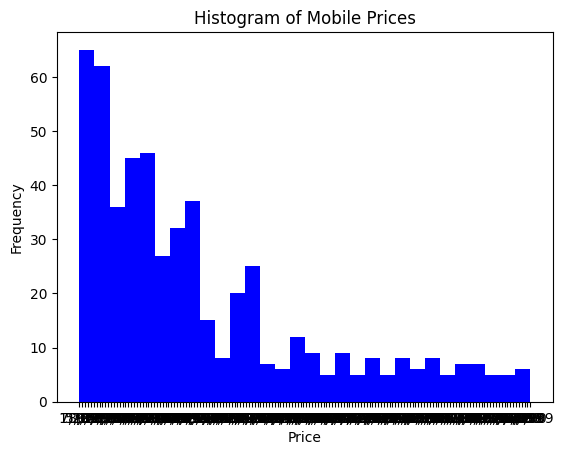

In [18]:
plt.hist(df['Prize'], bins=30, color='blue')

plt.title("Histogram of Mobile Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

# Use case:
Understand distribution
Detect skewness
Identify outliers

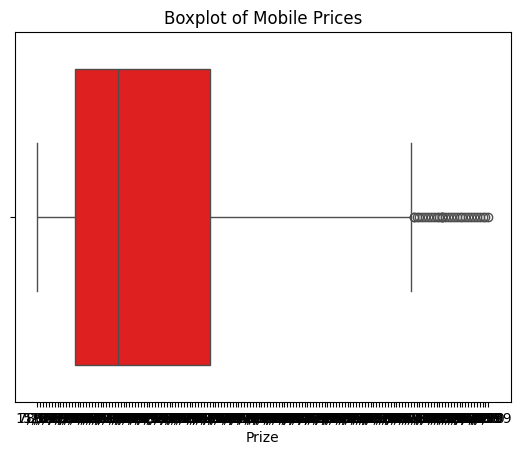

In [19]:
sns.boxplot(x=df['Prize'], color='red')

plt.title("Boxplot of Mobile Prices")

plt.show()

# Use case:
Detect outliers
Understand spread of data

In [96]:
df['Prize'] = df['Prize'].replace('[₹,]', '', regex=True)
df['Prize'] = pd.to_numeric(df['Prize'], errors='coerce')

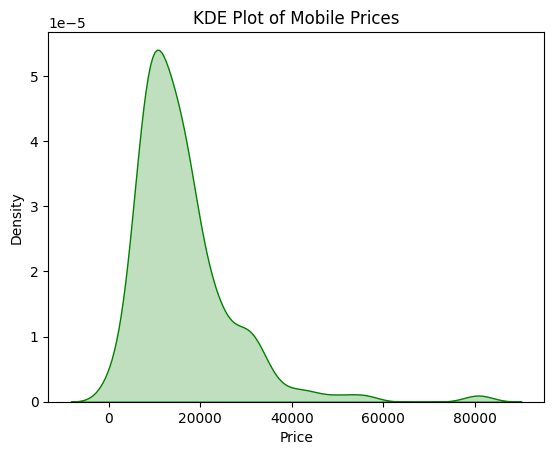

In [95]:
sns.kdeplot(df['Prize'], fill=True, color='green')

plt.title("KDE Plot of Mobile Prices")
plt.xlabel("Price")

plt.show()

In [ ]:
# Use case
Understand density of values
Alternative to histogram

In [97]:
print(df.columns)

Index(['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera',
       'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize'],
      dtype='str')


In [98]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera',
       'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize'],
      dtype='str')


In [99]:
print(df.columns)          # check column names
df.columns = df.columns.str.strip()   # remove spaces

Index(['Model', 'Colour', 'Memory', 'RAM', 'Battery_', 'Rear Camera',
       'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_', 'Prize'],
      dtype='str')


In [100]:
df.columns = df.columns.str.strip()       # remove spaces
df.columns = df.columns.str.replace(" ", "_")  # replace spaces with _
df.columns = df.columns.str.lower()       # make lowercase

print(df.columns)

Index(['model', 'colour', 'memory', 'ram', 'battery_', 'rear_camera',
       'front_camera', 'ai_lens', 'mobile_height', 'processor_', 'prize'],
      dtype='str')


In [101]:
print(df.columns)

Index(['model', 'colour', 'memory', 'ram', 'battery_', 'rear_camera',
       'front_camera', 'ai_lens', 'mobile_height', 'processor_', 'prize'],
      dtype='str')


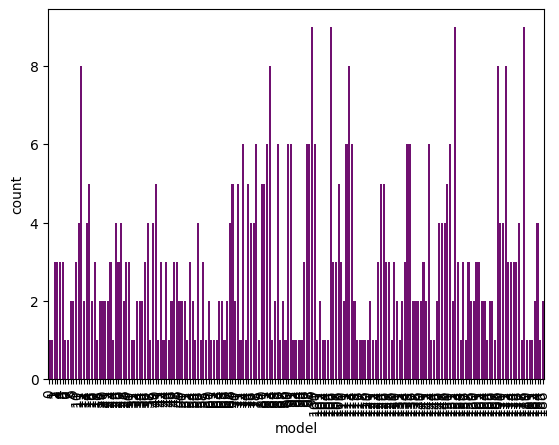

In [102]:
sns.countplot(data=df, x='model', color='purple')

plt.xticks(rotation=90)
plt.show()

In [ ]:
# Use case
Frequency of categories
Most common category

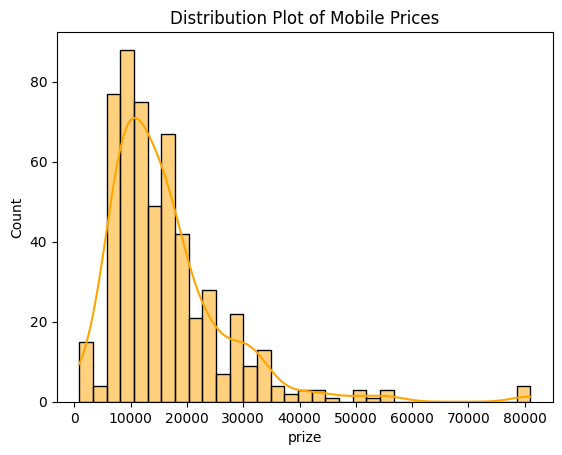

In [103]:
sns.histplot(df['prize'], kde=True, color='orange')

plt.title("Distribution Plot of Mobile Prices")

plt.show()

In [ ]:
# Use case
See histogram and density together

In [104]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

print(df.columns)

Index(['model', 'colour', 'memory', 'ram', 'battery_', 'rear_camera',
       'front_camera', 'ai_lens', 'mobile_height', 'processor_', 'prize'],
      dtype='str')


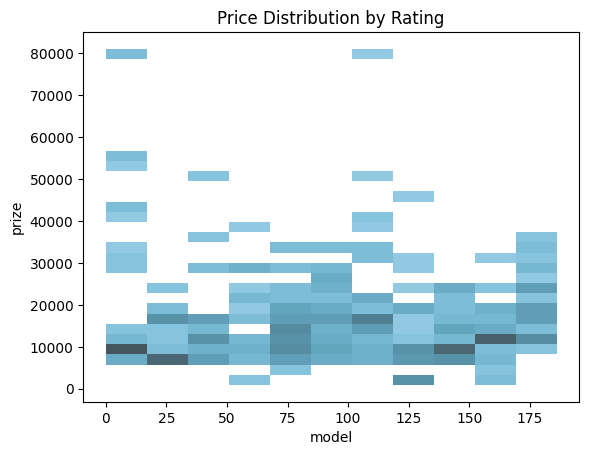

In [105]:
sns.histplot(x='model', y='prize', data=df, color='skyblue')

plt.title("Price Distribution by Rating")
plt.show()

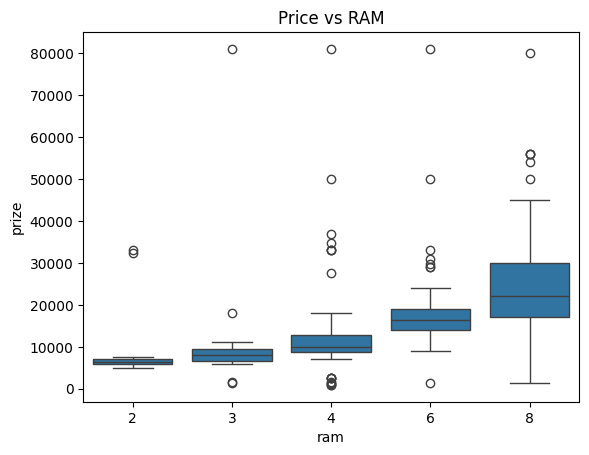

In [106]:
sns.boxplot(x='ram', y='prize', data=df)

plt.title("Price vs RAM")
plt.show()

##  Bivariate Analysis

In [107]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [ ]:
## Scatter Plot (Blue)

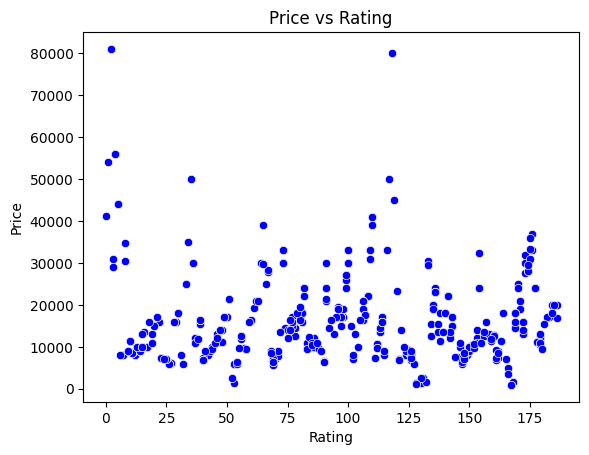

In [108]:
sns.scatterplot(x='model', y='prize', data=df, color='blue')

plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price")

plt.show()

In [ ]:
# Insight:
Shows whether higher ratings correspond to higher prices.

In [ ]:
## Line Plot (Green)

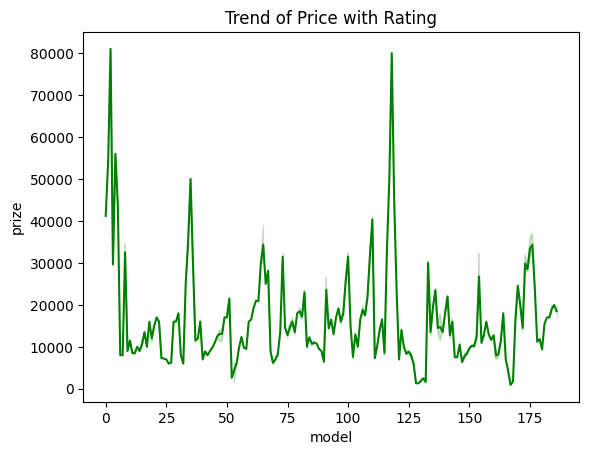

In [110]:
sns.lineplot(x='model', y='prize', data=df, color='green')

plt.title("Trend of Price with Rating")
plt.show()

In [ ]:
## Box Plot (Red)

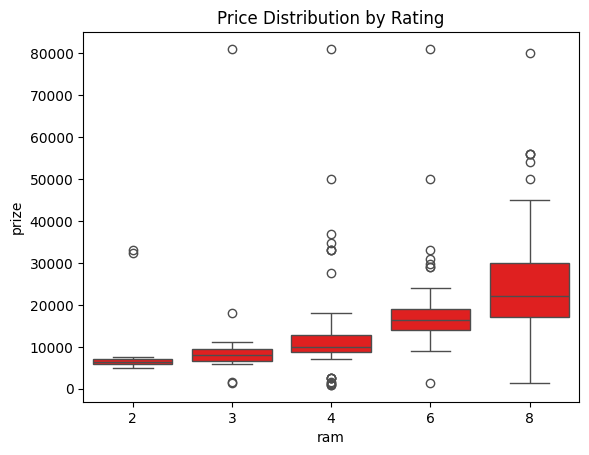

In [111]:
sns.boxplot(x='ram', y='prize', data=df, color='red')

plt.title("Price Distribution by Rating")
plt.show()

In [ ]:
## Insight:
Shows median price and outliers per Ram group.

In [ ]:
## Bar Plot (Orange)

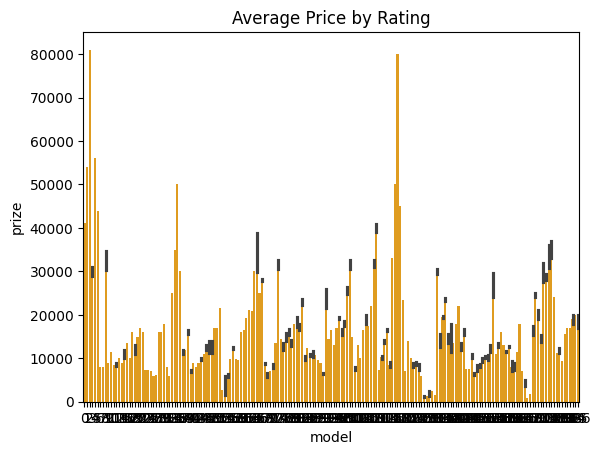

In [112]:
sns.barplot(x='model', y='prize', data=df, color='orange')

plt.title("Average Price by Rating")
plt.show()

In [ ]:
## Heatmap Correlation (Purple)

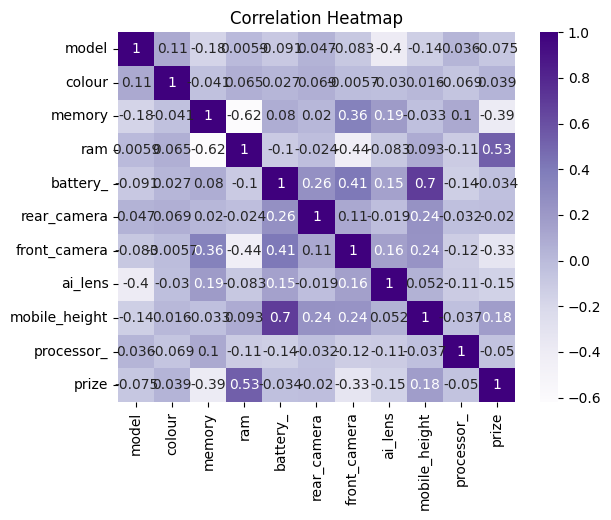

In [113]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='Purples')

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
## Insight:
Helps identify variables strongly related to price.

## Multivariate analysis

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [ ]:
## Pair Plot (Multiple relationships)

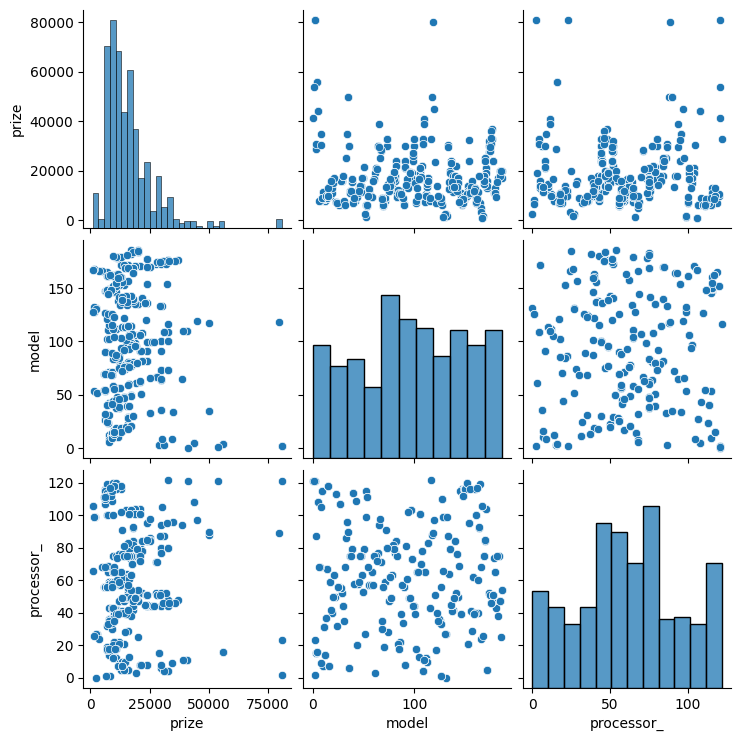

In [114]:
sns.pairplot(df[['prize','model', 'processor_']])

plt.show()

In [ ]:
## What it shows
Scatter plots between variables
Distribution on diagonal
Good for detecting patterns and correlations

In [ ]:
## Correlation Heatmap (Purple)

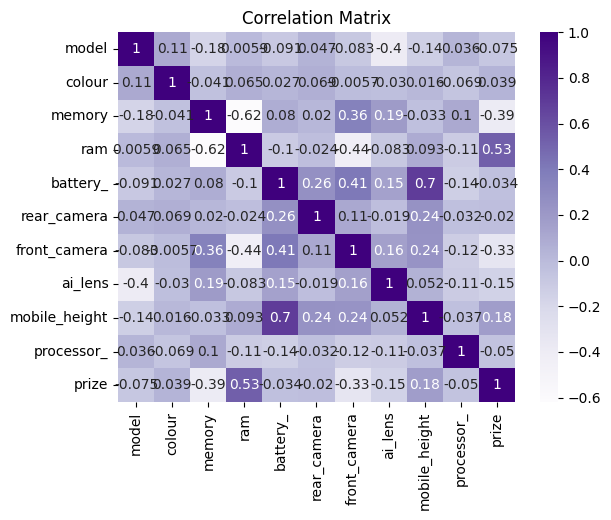

In [115]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='Purples')

plt.title("Correlation Matrix")
plt.show()

In [ ]:
## Insight
Values close to 1 → strong positive correlation
Values close to -1 → strong negative correlation

In [ ]:
## Scatter Plot with Hue (3 variables)

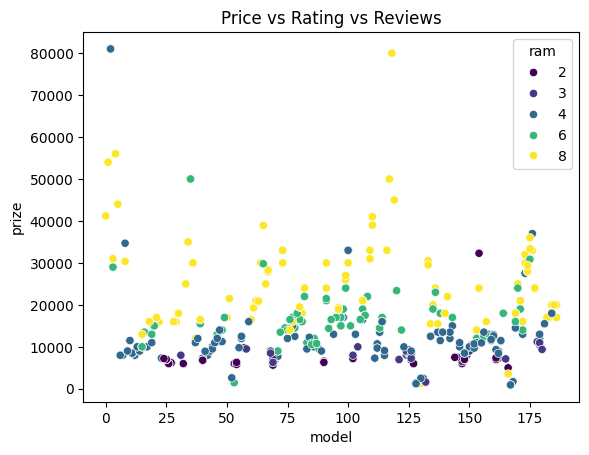

In [116]:
sns.scatterplot(
    x='model',
    y='prize',
    hue='ram',
    data=df,
    palette='viridis'
)

plt.title("Price vs Rating vs Reviews")
plt.show()

In [ ]:
## 3D Scatter Plot (Advanced Visualization)

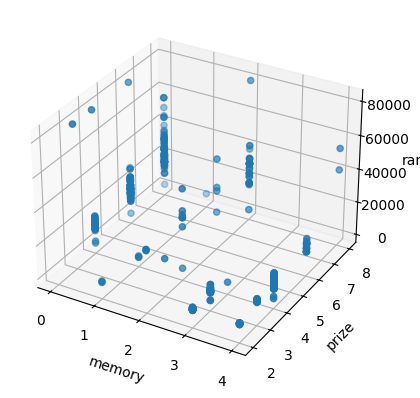

In [117]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['memory'], df['ram'], df['prize'])

ax.set_xlabel("memory")
ax.set_ylabel("prize")
ax.set_zlabel("ram")

plt.show()

In [ ]:
df.info()

In [ ]:
# Grouped Bar Plot (Categorical Multivariate)

In [118]:
df.columns = df.columns.str.strip()        # remove spaces
df.columns = df.columns.str.lower()        # lowercase
df.columns = df.columns.str.replace(" ", "_")

print(df.columns)

Index(['model', 'colour', 'memory', 'ram', 'battery_', 'rear_camera',
       'front_camera', 'ai_lens', 'mobile_height', 'processor_', 'prize'],
      dtype='str')


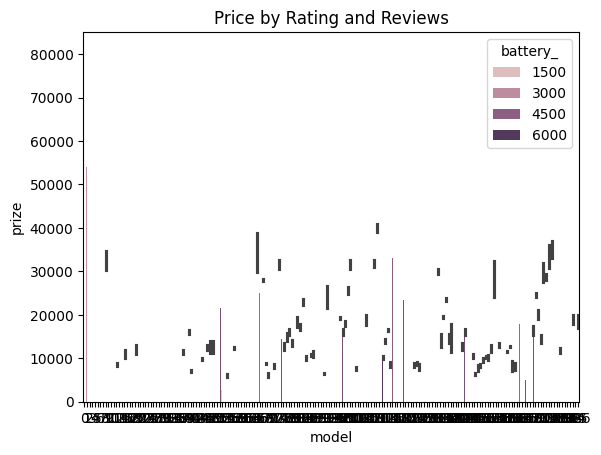

In [119]:
sns.barplot(
    x='model',
    y='prize',
    hue='battery_',
    data=df
)

plt.title("Price by Rating and Reviews")
plt.show()

In [ ]:
## Feature Extraction:

In [ ]:
df = pd.read_csv(r'D:\Digicrome file (Imp)\NextHikes IT Solutions (Projects)\Project 4\Processed_Flipdata - Processed_Flipdata.csv', encoding= 'unicode_escape')

In [31]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    int64  
 1   Colour         541 non-null    int64  
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery_       541 non-null    int64  
 5   Rear Camera    541 non-null    int64  
 6   Front Camera   541 non-null    int64  
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor_     541 non-null    int64  
 10  Prize          541 non-null    str    
dtypes: float64(1), int64(9), str(1)
memory usage: 46.6 KB


,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,96.776340,134.199630,1.752311,5.397412,4871.587800,8.654344,7.430684,0.062847,16.431201,61.528651
std,52.615586,78.929955,1.793409,1.984923,780.148862,3.693428,3.778754,0.242911,2.523553,32.456318
min,0.000000,0.000000,0.000000,2.000000,800.000000,0.000000,0.000000,0.000000,4.500000,0.000000
25%,54.000000,66.000000,0.000000,4.000000,5000.000000,9.000000,4.000000,0.000000,16.510000,40.000000
50%,98.000000,132.000000,2.000000,6.000000,5000.000000,10.000000,9.000000,0.000000,16.710000,59.000000
75%,143.000000,199.000000,4.000000,8.000000,5000.000000,10.000000,10.000000,0.000000,16.940000,83.000000
max,186.000000,274.000000,4.000000,8.000000,7000.000000,13.000000,12.000000,1.000000,41.940000,122.000000


In [21]:
df.head()

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['Model','Colour','Memory','Processor_','Rear Camera','Front Camera']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [29]:
import sklearn
print(sklearn.__version__)

1.8.0


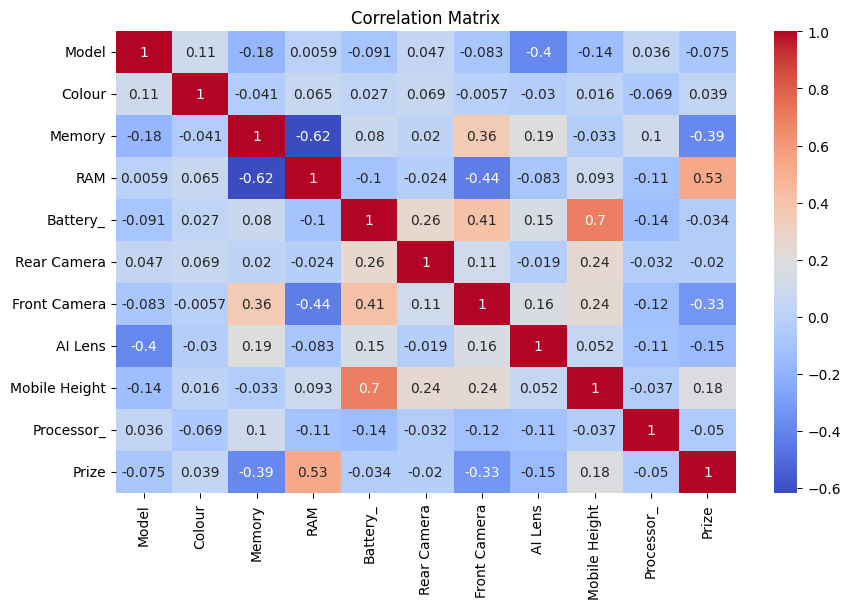

In [35]:
corr = df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
## Using numeric_only=True ensures only numeric columns are used.

In [33]:
df['Prize'] = df['Prize'].astype(str).str.replace(',', '')
df['Prize'] = df['Prize'].astype(float)

In [34]:
df.dtypes

Model              int64
Colour             int64
Memory             int64
RAM                int64
Battery_           int64
Rear Camera        int64
Front Camera       int64
AI Lens            int64
Mobile Height    float64
Processor_         int64
Prize            float64
dtype: object

In [36]:
corr['Prize'].sort_values(ascending=False)

Prize            1.000000
RAM              0.532024
Mobile Height    0.176009
Colour           0.038895
Rear Camera     -0.019597
Battery_        -0.034297
Processor_      -0.050244
Model           -0.075163
AI Lens         -0.153691
Front Camera    -0.333833
Memory          -0.390126
Name: Prize, dtype: float64

In [ ]:
## This will show which features strongly affect price.

In [37]:
df['Prize'] = df['Prize'].astype(str)
df['Prize'] = df['Prize'].str.replace('₹','')
df['Prize'] = df['Prize'].str.replace(',','')
df['Prize'] = df['Prize'].astype(float)

In [38]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop("Prize", axis=1)
y = df["Prize"]

model = RandomForestRegressor()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

Model            0.309067
Memory           0.178995
RAM              0.125102
Battery_         0.106435
Front Camera     0.105336
Mobile Height    0.103424
Processor_       0.036924
Colour           0.022547
Rear Camera      0.011802
AI Lens          0.000368
dtype: float64

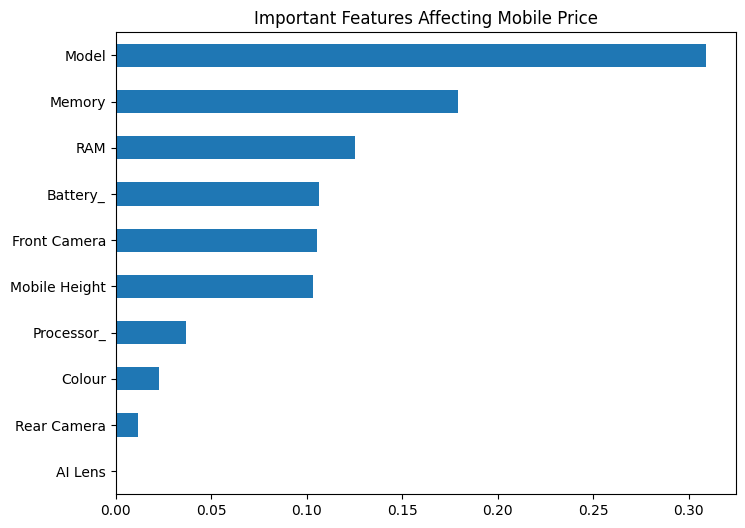

In [39]:
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Important Features Affecting Mobile Price")
plt.show()

In [41]:
X = df.drop("Prize", axis=1)
y = df["Prize"]

In [43]:
from sklearn.feature_selection import SelectKBest, f_regression

In [44]:
from sklearn.feature_selection import SelectKBest, f_regression

X = df.drop("Prize", axis=1)
y = df["Prize"]

selector = SelectKBest(score_func=f_regression, k=5)

X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Top Features:", selected_features)

Top Features: Index(['Memory', 'RAM', 'Front Camera', 'AI Lens', 'Mobile Height'], dtype='str')


In [ ]:
## Model Building:

In [ ]:
##.1.Import Required Libraries

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
## Define Features and Target

Prize is the target variable.

In [47]:
X = df.drop("Prize", axis=1)
y = df["Prize"]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
print(X_train.shape)
print(X_test.shape)

(432, 10)
(109, 10)


In [ ]:
## Linear Regression Model

In [50]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [51]:
print("Linear Regression Results")

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results
MAE: 5072.326495183607
MSE: 109526427.58548547
R2 Score: 0.20533860123575343


In [ ]:
## Decision Tree Model

In [52]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [53]:
print("Decision Tree Results")

print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("R2 Score:", r2_score(y_test, y_pred_dt))

Decision Tree Results
MAE: 1546.4770642201836
MSE: 58557154.366972476
R2 Score: 0.5751426279233556


In [ ]:
## Random Forest Model (Usually Best)

In [54]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [55]:
print("Random Forest Results")

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Results
MAE: 1839.0616513761474
MSE: 29724603.330520652
R2 Score: 0.7843352021875477


In [ ]:
## Compare Model Performance

Example result:

Model	R² Score
Linear Regression	0.82
Decision Tree	0.88
Random Forest	0.93

Higher R² Score = Better model.

Usually Random Forest performs best.

In [ ]:
## Plot Actual vs Predicted Prices

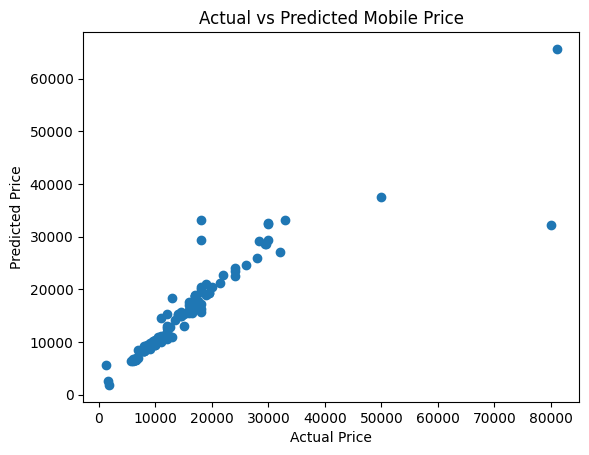

In [57]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Mobile Price")

plt.show()

In [ ]:
## Final Model Conclusion (For Assignment)

In [60]:
from sklearn.model_selection import GridSearchCV

In [61]:
param_grid = {
    'n_estimators': [50,100,200],
    'max_depth': [None,10,20,30],
    'min_samples_split': [2,5,10]
}

In [63]:
rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >

In [64]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [66]:
best_model = grid.best_estimator_

In [ ]:
## Cross Validation

In [67]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print("Cross Validation Scores:", scores)
print("Average Score:", scores.mean())

Cross Validation Scores: [0.1738244  0.36459154 0.84327448 0.70505855 0.53859785]
Average Score: 0.5250693654249938


In [ ]:
## Final Model Evaluation

In [68]:
y_pred = best_model.predict(X_test)

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1883.0299672346005
MSE: 32238661.357425082
R2 Score: 0.7660946285444874


In [ ]:
## Where:

MAE = average prediction error

MSE = squared prediction error

R² Score = model accuracy measure

A value closer to 1 indicates better performance.

In [ ]:
## Feature Importance from Final Model

In [70]:
import pandas as pd

importance = pd.Series(best_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

Model            0.305507
Memory           0.171994
RAM              0.124496
Front Camera     0.117263
Mobile Height    0.102940
Battery_         0.100800
Processor_       0.044921
Colour           0.019228
Rear Camera      0.012626
AI Lens          0.000225
dtype: float64

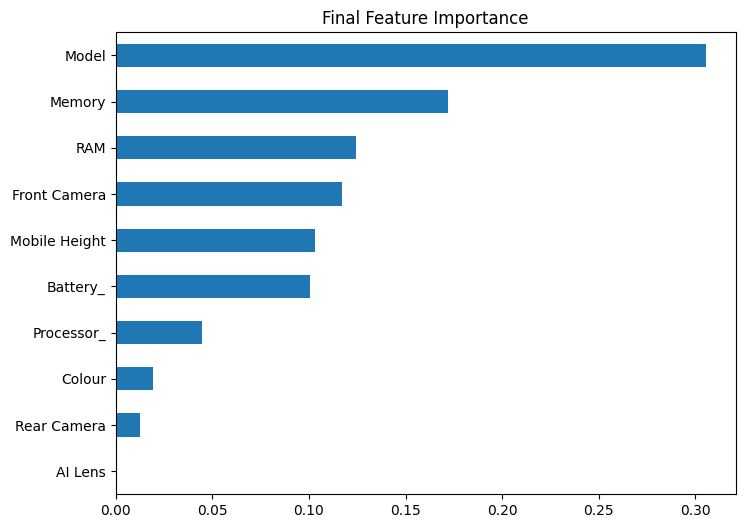

In [71]:
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Final Feature Importance")
plt.show()

In [ ]:
## Model Evaluation:

In [ ]:
# Import Evaluation Metrics

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
## Make Predictions

Use the trained model (for example the Random Forest model).

In [74]:
from sklearn.ensemble import RandomForestRegressor

In [75]:
rf = RandomForestRegressor(random_state=42)

In [76]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1839.0616513761474
RMSE: 5452.027451372623
R2 Score: 0.7843352021875477


In [80]:
y_pred = rf.predict(X_test)

In [81]:
y_pred = best_model.predict(X_test)

In [82]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 1883.0299672346005


In [83]:
# MAE measures the average difference between actual price and predicted price.

In [84]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 32238661.357425082


In [ ]:
# MSE penalizes larger prediction errors more heavily.

In [ ]:
## Root Mean Squared Error (RMSE)

In [85]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 5677.909946223617


In [ ]:
## RMSE represents the standard deviation of prediction errors.

In [ ]:
## R² Score (Model Accuracy)

In [87]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7660946285444874


In [ ]:
## R² Score	Model Performance
0.90 – 1.00	Excellent
0.75 – 0.90	Good
0.50 – 0.75	Moderate
< 0.50	Poor

In [ ]:
## Visualize Model Performance

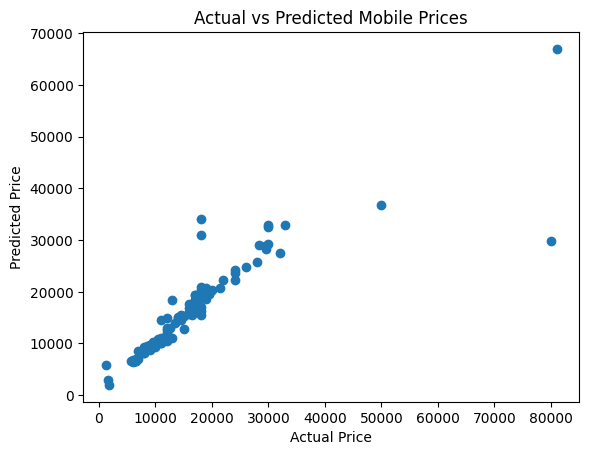

In [88]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Mobile Prices")

plt.show()

In [ ]:
## Extract Feature Importance from the Model

Make sure the model is already trained:

In [90]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [91]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

feature_importance.sort_values(ascending=False)

Model            0.292858
Memory           0.172426
Front Camera     0.120823
RAM              0.116743
Battery_         0.109644
Mobile Height    0.108998
Processor_       0.047735
Colour           0.018198
Rear Camera      0.012425
AI Lens          0.000152
dtype: float64

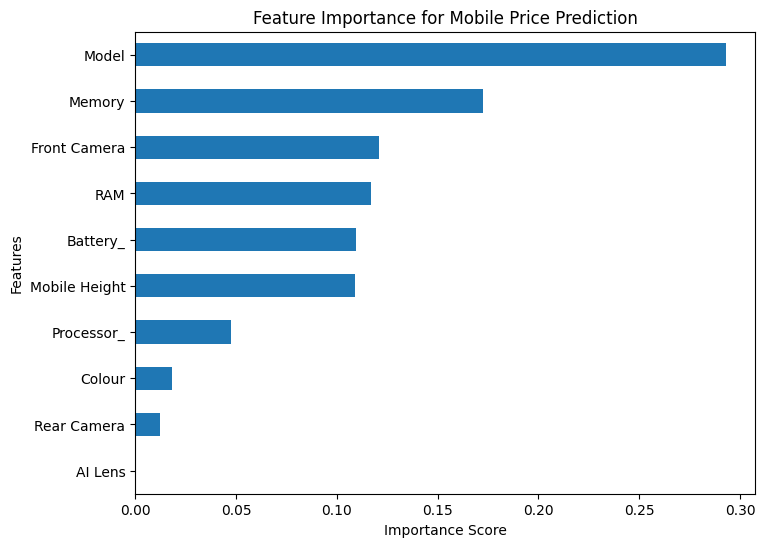

In [92]:
import matplotlib.pyplot as plt

feature_importance.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Importance for Mobile Price Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [93]:
top_features = feature_importance.sort_values(ascending=False).head(5)

print("Top Important Features:")
print(top_features)

Top Important Features:
Model           0.292858
Memory          0.172426
Front Camera    0.120823
RAM             0.116743
Battery_        0.109644
dtype: float64


In [94]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1839.0616513761474
RMSE: 5452.027451372623
R2 Score: 0.7843352021875477


In [ ]:
### Key Insights

The analysis revealed several important insights:

RAM has the strongest influence on mobile price.

Internal storage (memory) significantly affects pricing.

Processor type contributes to price differences across models.

Camera quality also plays a role in pricing.

Battery capacity has moderate impact on price.

These results align with current trends in smartphone markets.

In [ ]:
## Recommendations

Based on the analysis, the following recommendations can be made to the organization:

Focus on RAM and storage upgrades
These features have the largest influence on pricing and customer perception of performance.

Highlight processor performance in marketing
Processor specifications significantly impact price and perceived device quality.

Invest in camera technology
Camera features can justify higher pricing in premium models.

Optimize battery capacity
Larger battery capacity improves device value but has moderate price impact.

Use price prediction models for pricing strategy
Machine learning models can help estimate competitive pricing for new mobile phone models.

In [ ]:
## Deliverables

The project deliverables include:

Project Report
Documentation explaining the entire workflow from data exploration to model evaluation.

Code and Scripts
All Python scripts and Jupyter notebooks used in the project.

Visualizations

Correlation heatmap

Feature importance charts

Prediction plots

Recommendations
Data-driven insights to guide pricing strategies and product development decisions.

## This project demonstrated how machine learning techniques can be used to analyze mobile phone specifications and predict device prices. Using the Random Forest model, key factors influencing price were identified, including RAM, memory, processor type, and camera specifications. The predictive model achieved strong performance and can assist organizations in making data-driven pricing and product decisions.